<a href="https://colab.research.google.com/github/emilearthur/code4all/blob/master/DL_Pytorch/Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install colabcode 
from colabcode import ColabCode 
ColabCode(port=10000, password="emile")

  Created wheel for pyngrok: filename=pyngrok-4.1.11-cp36-none-any.whl size=16680 sha256=0977d206c14305c08c3c1b61aa8341aec4f1ac4ecf6acfd56e880e902838ba39
  Stored in directory: /root/.cache/pip/wheels/b9/d8/ae/5a29960e0fddbd2bf852bfa93d841dd8b1aa23851e81687f85
Successfully built pyngrok
Code Server can be accessed on: http://2dd90d7d2aef.ngrok.io
[2020-09-09T12:44:56.305Z] info  Wrote default config file to ~/.config/code-server/config.yaml
[2020-09-09T12:44:56.307Z] info  Using config file ~/.config/code-server/config.yaml
[2020-09-09T12:44:56.517Z] info  Using user-data-dir ~/.local/share/code-server
[2020-09-09T12:44:56.521Z] info  code-server 3.5.0 de41646fc402b968ca6d555fdf2da7de9554d28a
[2020-09-09T12:44:56.525Z] info  HTTP server listening on http://127.0.0.1:10000
[2020-09-09T12:44:56.525Z] info      - Using password from $PASSWORD
[2020-09-09T12:44:56.525Z] info      - To disable use `--auth none`
[2020-09-09T12:44:56.525Z] info    - Not serving HTTPS


# Preparing dataset 

In [ ]:
#!wget https://zenodo.org/record/3723295/files/annotations.csv
#!wget https://zenodo.org/record/3723295/files/candidates.csv
#!wget https://zenodo.org/record/3723295/files/candidates_V2.zip
#!wget https://zenodo.org/record/3723295/files/evaluationScript.zip
#!wget https://zenodo.org/record/3723295/files/sampleSubmission.csv
#!wget https://zenodo.org/record/3723295/files/seg-lungs-LUNA16.zip
!wget https://zenodo.org/record/3723295/files/subset4.zip
!wget https://zenodo.org/record/3723295/files/subset5.zip
!wget https://zenodo.org/record/3723295/files/subset6.zip

--2020-09-01 23:25:28--  https://zenodo.org/record/3723295/files/subset4.zip
Resolving zenodo.org (zenodo.org)... 188.184.117.155
Connecting to zenodo.org (zenodo.org)|188.184.117.155|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6856144330 (6.4G) [application/octet-stream]
Saving to: ‘subset4.zip’

subset4.zip         100%[===================>]   6.38G  14.9MB/s    in 9m 55s  

2020-09-01 23:35:25 (11.0 MB/s) - ‘subset4.zip’ saved [6856144330/6856144330]

--2020-09-01 23:35:25--  https://zenodo.org/record/3723295/files/subset5.zip
Resolving zenodo.org (zenodo.org)... 188.184.117.155
Connecting to zenodo.org (zenodo.org)|188.184.117.155|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6610460097 (6.2G) [application/octet-stream]
Saving to: ‘subset5.zip’

subset5.zip         100%[===================>]   6.16G  7.57MB/s    in 10m 51s 

2020-09-01 23:46:17 (9.69 MB/s) - ‘subset5.zip’ saved [6610460097/6610460097]

--2020-09-01 23:46:17-

In [ ]:
!sudo apt install p7zip-full p7zip-rar


Reading package lists... Done
Building dependency tree       
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-6).
The following package was automatically installed and is no longer required:
  libnvidia-common-440
Use 'sudo apt autoremove' to remove it.
The following NEW packages will be installed:
  p7zip-rar
0 upgraded, 1 newly installed, 0 to remove and 39 not upgraded.
Need to get 43.1 kB of archives.
After this operation, 113 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu bionic/multiverse amd64 p7zip-rar amd64 16.02-2 [43.1 kB]
Fetched 43.1 kB in 0s (89.2 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 76, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling

In [ ]:
!7z e -y subset4.zip
!mv *.mhd "/content/drive/My Drive/Data/Test/subset4"
!mv *.raw "/content/drive/My Drive/Data/Test/subset4"

!7z e -y subset5.zip
!mv *.mhd "/content/drive/My Drive/Data/Test/subset5"
!mv *.raw "/content/drive/My Drive/Data/Test/subset5"

!7z e -y subset6.zip
!mv *.mhd "/content/drive/My Drive/Data/Test/subset6"
!mv *.raw "/content/drive/My Drive/Data/Test/subset6"


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 6856144330 bytes (6539 MiB)

Extracting archive: subset4.zip

ERRORS:
Headers Error

--
Path = subset4.zip
Type = zip
ERRORS:
Headers Error
Physical Size = 6856144330
64-bit = +

  0%      0% 1 - subset4/1.3.6.1.4.1.14519.5.2.1.6 . 100530488926682752765845212286.raw                                                                                 1% 1 - subset4/1.3.6.1.4.1.14519.5.2.1.6 . 100530488926682752765845212286.raw                                                        

# 



# Data Preprocessing

In [1]:
!free -h
!nvidia-smi -L
!nvidia-smi
!nvcc --version
!lscpu |grep 'Model name'
!lscpu |grep 'Core(s) per socket:'
!lscpu |grep 'Thread(s) per core'

              total        used        free      shared  buff/cache   available
Mem:            12G        569M         10G        976K        2.1G         11G
Swap:            0B          0B          0B
GPU 0: Tesla T4 (UUID: GPU-de95789c-687d-0e73-67d6-9ab264ee1f61)
Sun Sep 13 02:41:44 2020       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 450.66       Driver Version: 418.67       CUDA Version: 10.1     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   44C    P8     9W /  70W |      0MiB / 15079MiB |   

In [2]:
!wc -l "/content/drive/My Drive/Data/Test/candidates.csv"
!tail "/content/drive/My Drive/Data/Test/candidates.csv"

!grep ",1$" "/content/drive/My Drive/Data/Test/candidates.csv" | wc -l

551066 /content/drive/My Drive/Data/Test/candidates.csv
1.3.6.1.4.1.14519.5.2.1.6279.6001.997611074084993415992563148335,47.6820308725,39.7555086022,-180.172305884,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.997611074084993415992563148335,-63.37,40.04,-112.53,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.997611074084993415992563148335,-78.09,-11.12,-103.41,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.997611074084993415992563148335,-24.82,41.44,-145.49,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.997611074084993415992563148335,10.92,16.21,-8.74,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.997611074084993415992563148335,-55.66,37.24,-110.42,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.997611074084993415992563148335,68.4,70.18,-109.72,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.997611074084993415992563148335,-82.29,-27.94,-106.92,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.997611074084993415992563148335,38.26,83.5,-102.71,0
1.3.6.1.4.1.14519.5.2.1.6279.6001.997611074084993415992563148335,-63.37,-9.71,-111.12,0
0


In [3]:
!wc -l "/content/drive/My Drive/Data/Test/annotations.csv"
!head "/content/drive/My Drive/Data/Test/annotations.csv"


1187 /content/drive/My Drive/Data/Test/annotations.csv
seriesuid,coordX,coordY,coordZ,diameter_mm
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,-128.6994211,-175.3192718,-298.3875064,5.651470635
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,103.7836509,-211.9251487,-227.12125,4.224708481
1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793540579077826395208,69.63901724,-140.9445859,876.3744957,5.786347814
1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405,-24.0138242,192.1024053,-391.0812764,8.143261683
1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405,2.441546798,172.4648812,-405.4937318,18.54514997
1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405,90.93171321,149.0272657,-426.5447146,18.20857028
1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405,89.54076865,196.4051593,-515.0733216,16.38127631
1.3.6.1.4.1.14519.5.2.1.6279.6001.100953483028192176989979435275,81.50964574,54.9572186,-150.3464233,10

In [4]:
# Training and Validation sets 
!grep 100225287222365663678666836860 "/content/drive/My Drive/Data/Test/annotations.csv"
!grep '100225287222365663678666836860.*,1$' "/content/drive/My Drive/Data/Test/candidates.csv"

1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,-128.6994211,-175.3192718,-298.3875064,5.651470635
1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860,103.7836509,-211.9251487,-227.12125,4.224708481


# Combining data sources into a unified dataset
(Data Preprocessing)


In [5]:
!mkdir src 
!touch src/__init__.py
!mkdir src/util
!touch src/util/__init__.py

In [33]:
%%writefile src/dsets.py
# import libaries 
from collections import namedtuple
import functools
import os
import glob 
import csv
import SimpleITK as sitk
import numpy as np 
import torch 
import copy
import random
import math

import torch 
import torch.nn.functional as F 

from torch.utils.data import Dataset
from src.util.util import XyzTuple, xyz2irc #change to from src.util.util import XyzTuple, xyz2irc in future
from src.util.disk import getCache 
from src.util.logconf import logging

log = logging.getLogger(__name__)
log.setLevel(logging.DEBUG)

raw_cache = getCache("src_raw")

CandidateInfoTuple = namedtuple("CandidateInfoTuple", 
                                "isNodule_bool, diameter_mm, series_uid, center_xyz")

@functools.lru_cache(1) # standard caching in-memory library 
def getCandidateInfoList(requireOnDisk_bool=True):
    """
    Notes in Code below: For each of the candidate entries for a given series_uid, we loop through the annotation collected earlier for the same 
    series_uid and see if the two coordincates are close enought to consider them the same nodule. 
    If they match we have the diameterof that nodule else we treat the nodule of having 0.0 diameter. 
    """
    mhd_list = glob.glob('/content/drive/My Drive/Data/Test/subset*/*.mhd')
    presentOnDisk_set = {os.path.split(p)[-1][:-4] for p in mhd_list}

    diameter_dict = {}
    with open("/content/drive/My Drive/Data/Test/annotations.csv", "r") as f:
        for row in list(csv.reader(f))[1:]:
            series_uid = row[0]
            annotationCenter_xyz = tuple([float(x) for x in row[1:4]])
            annotationDiameter_mm = float(row[4])

            diameter_dict.setdefault(series_uid, []).append(
                (annotationCenter_xyz, annotationDiameter_mm))

    candidateInfo_list = []
    with open("/content/drive/My Drive/Data/Test/candidates.csv", "r") as f:
        for row in list(csv.reader(f))[1:]:
            series_uid = row[0]

            if series_uid not in presentOnDisk_set and requireOnDisk_bool:
                continue

            isNodule_bool = bool(int(row[4]))
            candidateCenter_xyz = tuple([float(x) for x in row[1:4]])

            candidateDiameter_mm = 0.0
            for annotation_tuple in diameter_dict.get(series_uid, []):
                annotationCenter_xyz, annotationDiameter_mm = annotation_tuple
                for i in range(3):
                    delta_mm = abs(candidateCenter_xyz[i] - annotationCenter_xyz[i])
                    if delta_mm > annotationDiameter_mm / 4:
                        break
                else:
                    candidateDiameter_mm = annotationDiameter_mm
                    break
    
            candidateInfo_list.append(CandidateInfoTuple(isNodule_bool,
                                                         candidateDiameter_mm, series_uid, candidateCenter_xyz, ))

    candidateInfo_list.sort(reverse=True)
    return candidateInfo_list


class Ct:
    def __init__(self, series_uid):
        mhd_path = glob.glob("/content/drive/My Drive/Data/Test/subset*/{}.mhd".format(series_uid))[0]

        ct_mhd = sitk.ReadImage(mhd_path) # consumes image from .mhd files.
        ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
        ct_a.clip(-1000, 1000, ct_a)
        self.series_uid = series_uid 
        self.hu_a = ct_a

        self.origin_xyz = XyzTuple(*ct_mhd.GetOrigin())
        self.vxSize_xyz = XyzTuple(*ct_mhd.GetSpacing()) 
        self.direction_a = np.array(ct_mhd.GetDirection()).reshape(3,3)
        

    def getRawCandidate(self, center_xyz, width_irc):
        """
        Takes the center expressed in the patient coordinate system (X, Y, Z) just as specified in the LUNA CSV data, 
        and the width in voxel and returns a cubic chunk of CT and the center of the candidate converted to array 
        coordinate. 
        """
        center_irc = xyz2irc(center_xyz, self.origin_xyz, self.vxSize_xyz, self.direction_a,)
        slice_list = [] 
        for axis, center_val in enumerate(center_irc):
            start_ndx = int(round(center_val - width_irc[axis]/2))
            end_ndx = int(start_ndx + width_irc[axis]) 

            assert center_val  >= 0 and center_val < self.hu_a.shape[axis], repr([self.series_uid, center_xyz, self.origin_xyz, self.vxSize_xyz, center_irc, axis])

            if start_ndx < 0:
                start_ndx = 0
                end_ndx = int(width_irc[axis]) 

            if end_ndx > self.hu_a.shape[axis]:
                end_ndx = self.hu_a.shape[axis]
                start_ndx = int(self.hu_a.shape[axis] - width_irc[axis])

            slice_list.append(slice(start_ndx, end_ndx))

        ct_chunk = self.hu_a[tuple(slice_list)]
        return ct_chunk, center_irc



@functools.lru_cache(1, typed=True)
def getCt(series_uid):
    return Ct(series_uid)

@raw_cache.memoize(typed=True) 
def getCtRawCandidate(series_uid, center_xyz, width_irc):
    ct = getCt(series_uid)
    ct_chunk, center_irc = ct.getRawCandidate(center_xyz, width_irc)
    return ct_chunk, center_irc

def getCtAugmentedCandidate(augmentation_dict, series_uid, center_xyz, width_irc, use_cache=True):
    if use_cache:
        ct_chunk, center_irc = getCtRawCandidate(series_uid, center_xyz, width_irc)
    else:
        ct = getCt(series_uid) 
        ct__chunk, center_irc = ct.getRawCandidate(center_xyz, width_irc)

    ct_t = torch.tensor(ct_chunk).unsqueeze(0).unsqueenze(0).to(torch.float32)

    transform_t = torch.eye(4)
    for i in range(3):
        if "flip" in augmentation_dict:
            if random.random() > 0.5:
                transform_t[i, i] *= -1
        if "offset" in augmentation_dict:
            offset_float = augmentation_dict["offset"] 
            random_float = (random.random() * 2 - 1) 
            transform_t[i, 3] = offset_float * random_float 
        if "scale" in augmentation_dict:
            scale_float = augmentation_dict["scale"]
            random_float = (random.random() * 2 - 1)
            transform_t[i, i] *= 1.0 + scale_float + random_float
    if "rotate" in augmentation_dict:
        angle_rad = random.random() * math.pi * 2
        s = math.sin(angle_rad) 
        c = math.cos(angle_rad) 
        rotation_t = torch.tensor([[c, -s, 0, 0],
                                   [s, c, 0, 0],
                                   [0, 0, 1, 0],
                                   [0, 0, 0, 1],])
        transform_t @= rotation_t
    affine_t = F.affine_grid(transform_t[:3].unsqueeze(0).to(torch.float32),
                             ct_t.size(),
                             align_corners=False, )
    augmented_chunk = F.grid_sample(ct_t, affine_t, padding_mode='border',
                                    align_corners=False,).to('cpu') 
    if "noise" in augmentation_dict:
        noise_t = torch.randn_like(augmented_chunk) 
        noise_t *= augmentation_dict["noise"]
        augmented_chunk += noise_t 
    return augmented_chunk[0], center_irc

class LunaDataset(Dataset):
    def __init__(self, val_stride=0, isValSet_bool=None, series_uid=None, sortby_str="random", ratio_int=0,
                 augmentation_dict=None, candidateInfo_list=None, ):
        self.ratio_int = ratio_int 
        self.augmentation_dict = augmentation_dict

        if candidateInfo_list:
            self.candidateInfo_list = copy.copy(getCandidateInfoList)
            self.use_cache = False
        else:
            self.candidateInfo_list = copy.copy(getCandidateInfoList())
            self.use_cache = True

        if series_uid:
            self.candidateInfo_list = [x for x in self.candidateInfo_list if x.series_uid == series_uid]

        # training/validation split 
        if isValSet_bool:
            assert val_stride > 0, val_stride 
            self.candidateInfo_list = self.candidateInfo_list[::val_stride]
            assert self.candidateInfo_list
        elif val_stride > 0:
            del self.candidateInfo_list[::val_stride] # Deletes the validation images (every val_stide-th item in the list) from self.candidateInf_list. 
            assert self.candidateInfo_list
        
        if sortby_str == 'random':
            random.shuffle(self.candidateInfo_list)
        elif sortby_str == 'series_uid':
            self.candidateInfo_list.sort(key=lambda x: (x.series_uid, x.center_xyz))
        elif sortby_str == 'label_and_size':
            pass
        else:
            raise Exception("Unknown sort: " + repr(sortby_str))

        self.negative_list = [nt for nt in self.candidateInfo_list if not nt.isNodule_bool] 
        self.positive_list =  [nt for nt in self.candidateInfo_list if nt.isNodule_bool]

        #log.info("{!r}: {} {} samples".format(
        #    self,
        #    len(self.candidateInfo_list),
        #    "validation" if isValSet_bool else "training",
        #))
        log.info("{!r}: {} {} samples, {} neg, {} pos, {} ratio".format(
            self,
            len(self.candidateInfo_list),
            "validation" if isValSet_bool else "training",
            len(self.negative_list),
            len(self.positive_list),
            "{}:1".format(self.ratio_int) if self.ratio_int else "unbalanced"
        ))
    
    def shuffleSample(self):
        if self.ratio_int:
            random.shuffle(self.negative_list) 
            random.shuffle(self.positive_list)

    def __len__(self):
        if self.ratio_int:
            return 200000
        else:
            return len(self.candidateInfo_list) 
    
    def __getitem__(self, ndx):
        """
        #old code
        candidateInfo_tuple = self.candidateInfo_list[ndx]
        width_irc = (32, 48, 48)

        candidate_a, center_irc = getCtRawCandidate(candidateInfo_tuple.series_uid,
                                                candidateInfo_tuple.center_xyz, 
                                                width_irc,)
        candidate_t = torch.from_numpy(candidate_a).to(torch.float32)
        candidate_t = candidate_t.unsqueeze(0) # unsqueeze(0) adds the channel dimension

        pos_t = torch.tensor([not candidateInfo_tuple.isNodule_bool, candidateInfo_tuple.isNodule_bool],
                            dtype=torch.long,)


        return (candidate_t, #bring out 
                pos_t, 
                candidateInfo_tuple.series_uid,
                torch.tensor(center_irc),)
        """
        if self.ratio_int:
            pos_ndx = ndx // (self.ratio_int + 1)

            if ndx % (self.ratio_int + 1):
                neg_ndx = ndx - 1 - pos_ndx 
                neg_ndx %= len(self.negative_list)
                candidateInfo_tuple = self.negative_list[neg_ndx] 
            else:
                pos_ndx %= len(self.positive_list) 
                candidateInfo_tuple = self.positive_list[pos_ndx] 
        else:
            candidateInfo_tuple = self.candidateInfo_list[ndx]
        
        width_irc = (32, 48, 48) 
        if self.augmentation_dict:
            candidate_t, center_irc = getCtAugmentedCandidate(self.augmentation_dict, 
                                                              candidateInfo_tuple.series_uid,
                                                              candidateInfo_tuple.center_xyz, 
                                                              width_irc, 
                                                              self.use_cache,)
        elif self.use_cache:
            candidate_a, center_irc = getCtRawCandidate(candidateInfo_tuple.series_uid,
                                                        candidateInfo_tuple.center_xyz, 
                                                        width_irc,)
            candidate_t = torch.from_numpy(candidate_a).to(torch.float32) 
            candidate_t = candidate_t.unsqueeze(0)
        else:
            ct = getCt(candidateInfo_tuple.series_uid)
            candidate_a, center_irc = getCtRawCandidate(candidateInfo_tuple.series_uid,
                                                candidateInfo_tuple.center_xyz, 
                                                width_irc,)
            candidate_t = torch.from_numpy(candidate_a).to(torch.float32) 
            candidate_t = candidate_t.unsqueeze(0) 
        
        pos_t = torch.tensor([not candidateInfo_tuple.isNodule_bool,
                              candidateInfo_tuple.isNodule_bool], dtype=torch.long, )
        return candidate_t, pos_t, candidateInfo_tuple.series_uid, torch.tensor(center_irc)
         

Overwriting src/dsets.py


In [7]:
%%writefile src/vis.py
import numpy as np 
import matplotlib.pyplot as plt 

from src.dsets import Ct, LunaDataset 


clim=(-1000.0, 300)

def findPositiveSamples(start_ndx=0, limit=100):
    ds = LunaDataset(sortby_str='label_and_size')

    positiveSample_list = []
    for sample_tup in ds.candidateInfo_list:
        if sample_tup.isNodule_bool:
            print(len(positiveSample_list), sample_tup)
            positiveSample_list.append(sample_tup)

        if len(positiveSample_list) >= limit:
            break

    return positiveSample_list

def showCandidate(series_uid, batch_ndx=None, **kwargs):
    ds = LunaDataset(series_uid=series_uid, **kwargs)
    pos_list = [i for i, x in enumerate(ds.candidateInfo_list) if x.isNodule_bool]

    if batch_ndx is None:
        if pos_list:
            batch_ndx = pos_list[0]
        else:
            print("Warning: no positive samples found; using first negative sample.")
            batch_ndx = 0

    ct = Ct(series_uid)
    ct_t, pos_t, series_uid, center_irc = ds[batch_ndx]
    ct_a = ct_t[0].numpy()

    fig = plt.figure(figsize=(30, 50))

    group_list = [
        [9, 11, 13],
        [15, 16, 17],
        [19, 21, 23],
    ]

    subplot = fig.add_subplot(len(group_list) + 2, 3, 1)
    subplot.set_title('index {}'.format(int(center_irc[0])), fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(ct.hu_a[int(center_irc[0])], clim=clim, cmap='gray')

    subplot = fig.add_subplot(len(group_list) + 2, 3, 2)
    subplot.set_title('row {}'.format(int(center_irc[1])), fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(ct.hu_a[:,int(center_irc[1])], clim=clim, cmap='gray')
    plt.gca().invert_yaxis()

    subplot = fig.add_subplot(len(group_list) + 2, 3, 3)
    subplot.set_title('col {}'.format(int(center_irc[2])), fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(ct.hu_a[:,:,int(center_irc[2])], clim=clim, cmap='gray')
    plt.gca().invert_yaxis()

    subplot = fig.add_subplot(len(group_list) + 2, 3, 4)
    subplot.set_title('index {}'.format(int(center_irc[0])), fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(ct_a[ct_a.shape[0]//2], clim=clim, cmap='gray')

    subplot = fig.add_subplot(len(group_list) + 2, 3, 5)
    subplot.set_title('row {}'.format(int(center_irc[1])), fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(ct_a[:,ct_a.shape[1]//2], clim=clim, cmap='gray')
    plt.gca().invert_yaxis()

    subplot = fig.add_subplot(len(group_list) + 2, 3, 6)
    subplot.set_title('col {}'.format(int(center_irc[2])), fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(ct_a[:,:,ct_a.shape[2]//2], clim=clim, cmap='gray')
    plt.gca().invert_yaxis()

    for row, index_list in enumerate(group_list):
        for col, index in enumerate(index_list):
            subplot = fig.add_subplot(len(group_list) + 2, 3, row * 3 + col + 7)
            subplot.set_title('slice {}'.format(index), fontsize=30)
            for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
                label.set_fontsize(20)
            plt.imshow(ct_a[index], clim=clim, cmap='gray')


    print(series_uid, batch_ndx, bool(pos_t[0]), pos_list)


Writing src/vis.py


In [8]:
%%writefile src/util/util.py
from collections import namedtuple
import copy 
import datetime 
import time 
import gc 
import numpy as np 

from src.util.logconf import logging
log = logging.getLogger(__name__)
log.setLevel(logging.DEBUG)


IrcTuple = namedtuple("IrcTuple", ["index", "row", "col"]) 
XyzTuple = namedtuple("XyzTuple", ["x", "y", "z"])

def irc2xyz(coord_irc, origin_xyz, vxSize_xyz, direction_a):
  cri_a = np.array(coord_irc)[::-1] 
  origin_a = np.array(origin_xyz)
  vxSize_a = np.array(vxSize_xyz)
  coord_xyz = (direction_a @ (cri_a * vxSize_a)) + origin_a
  return XyzTuple(*coord_xyz)

def xyz2irc(coord_xyz, origin_xyz, vxSize_xyz, direction_a):
  origin_a = np.array(origin_xyz) 
  vxSize_a = np.array(vxSize_xyz)
  coord_a = np.array(coord_xyz)
  cri_a = np.around(((coord_a - origin_a) @ np.linalg.inv(direction_a)) / vxSize_a)
  return IrcTuple(int(cri_a[2]), int(cri_a[1]), int(cri_a[0]))

def importstr(module_str, from_=None):
    if from_ is None and ":" in module_str:
        module_str, from_ = module_str.rsplit(":")

    module = __import__(module_str) 
    for sub_str in module_str.split(".")[1:]:
        module = getattr(module, sub_str)

    if from_:
        try:
            return getattr(module, from_)
        except:
            raise ImportError("{}.{}".format(module_str, from_))
    return module

def prhist(ary, prefix_str=None, **kwargs):
    if prefix_str is None:
        prefix_str = ''
    else:
        prefix_str += ' '

    count_ary, bins_ary = np.histogram(ary, **kwargs)
    for i in range(count_ary.shape[0]):
        print("{}{:-8.2f}".format(prefix_str, bins_ary[i]), "{:-10}".format(count_ary[i]))
    print("{}{:-8.2f}".format(prefix_str, bins_ary[-1]))

def enumerateWithEstimate(iter, desc_str, start_ndx=0, print_ndx=4, backoff=None, iter_len=None, ):
    if iter_len is None:
        iter_len = len(iter)

    if backoff is None:
        backoff = 2
        while backoff ** 7 < iter_len:
            backoff *= 2

    assert backoff >= 2
    while print_ndx < start_ndx * backoff:
        print_ndx *= backoff

    log.warning("{} ----/{}, starting".format(desc_str, iter_len, ))
    start_ts = time.time()
    for (current_ndx, item) in enumerate(iter):
        yield (current_ndx, item)
        if current_ndx == print_ndx:
            duration_sec = ((time.time() - start_ts)
                            / (current_ndx - start_ndx + 1)
                            * (iter_len-start_ndx))

            done_dt = datetime.datetime.fromtimestamp(start_ts + duration_sec)
            done_td = datetime.timedelta(seconds=duration_sec)

            log.info("{} {:-4}/{}, done at {}, {}".format(desc_str, current_ndx, iter_len,
                                                          str(done_dt).rsplit('.', 1)[0],
                                                          str(done_td).rsplit('.', 1)[0],))

            print_ndx *= backoff

        if current_ndx + 1 == start_ndx:
            start_ts = time.time()

    log.warning("{} ----/{}, done at {}".format(desc_str, iter_len,
                                                str(datetime.datetime.now()).rsplit('.', 1)[0], ))





Writing src/util/util.py


In [9]:

%%writefile src/util/disk.py
import gzip 

from diskcache import FanoutCache, Disk 
from diskcache.core import BytesType, MODE_BINARY, BytesIO

from src.util.logconf import logging
log = logging.getLogger(__name__)
log.setLevel(logging.INFO)


class GzipDisk(Disk):
    def store(self, value, read, key=None):
        """
        Override from base class diskcache.Disk.
        """
        if type(value) is BytesType:
            if read:
                value = value.read() 
                read = False 
            
            str_io = BytesIO()
            gz_file = gzip.GzipFile(mode="wb", compresslevel=1, fileobj=str_io) 

            for offset in range(0, len(value),  2**30):
                gz_file.write(value[offset:offset+2**30]) 
            gz_file.close()

            value = str_io.getvale() 
        return super(GzipDisk, self).store(value, read)
    
    def fetch(self, mode, filename, value, read):
        """
        Override from based class diskcache.Disk
        """
        value = super(GzipDisk, self).fetch(mode, filename, value, read) 

        if mode == MODE_BINARY:
            str_io = BytesIO(value) 
            gz_file = gzip.GzipFile(mode="rb", fileobj=str_io)
            read_csio = BytesIO() 

            while True:
                uncompressed_data = gz_file.read(2**30)
                if uncompressed_data:
                    read_csio.write(uncompressed_data)
                else:
                    break 
                
            value = read_csio.getvalue() 
        return value 
    
def getCache(scope_str):
    return FanoutCache('data-unversioned/cache/'+ scope_str, disk=GzipDisk, 
                        shards=64, timeout=1, size_limit=3e11,)




Writing src/util/disk.py


In [10]:
%%writefile src/util/logconf.py
import logging 
import logging.handlers 

root_logger = logging.getLogger()
root_logger.setLevel(logging.INFO) 

# Avoiding attempts from other libraries 
for handler in list(root_logger.handlers):
    root_logger.removeHandler(handler) 

logfmt_str = "%(asctime)s %(levelname)-8s pid:%(process)d %(name)s:%(lineno)03d:%(funcName)s %(message)s"
formatter = logging.Formatter(logfmt_str) 

streamHandler = logging.StreamHandler() 
streamHandler.setFormatter(formatter) 
streamHandler.setLevel(logging.DEBUG)

root_logger.addHandler(streamHandler)

Writing src/util/logconf.py


# Testing Code above 


In [11]:
#!pip install SimpleITK
!pip install "SimpleITK==1.2.3"
!pip install "diskcache==4.1.0"

import numpy as np
from src.dsets import getCandidateInfoList, LunaDataset, getCt
%matplotlib inline 
from src.vis import findPositiveSamples, showCandidate

import matplotlib.pyplot as plt

     |████████████████████████████████| 42.5MB 68kB/s 
     |████████████████████████████████| 51kB 4.1MB/s 


In [12]:
candidateInfo_list = getCandidateInfoList(requireOnDisk_bool=False)
positiveInfo_list = [x for x in candidateInfo_list if x[0]]
diameter_list = [x[1] for x in positiveInfo_list]
print(len(positiveInfo_list))
print(positiveInfo_list[0])

for i in range(0, len(diameter_list), 100):
    print("{:4} {:4.1f} mm".format(i, diameter_list[i]))

1351
CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(67.61451718, 85.02525992, -109.8084416))
   0 32.3 mm
 100 17.7 mm
 200 13.0 mm
 300 10.0 mm
 400  8.2 mm
 500  7.0 mm
 600  6.3 mm
 700  5.7 mm
 800  5.1 mm
 900  4.7 mm
1000  4.0 mm
1100  0.0 mm
1200  0.0 mm
1300  0.0 mm


In [13]:
for candidateInfo_tuple in positiveInfo_list[:10]:
    print(candidateInfo_tuple)

print("\n")
for candidateInfo_tuple in positiveInfo_list[-10:]:
    print(candidateInfo_tuple)

print("\n")

for candidateInfo_tuple in positiveInfo_list:
    if candidateInfo_tuple.series_uid.endswith("565"):
        print(candidateInfo_tuple)



CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(67.61451718, 85.02525992, -109.8084416))
CandidateInfoTuple(isNodule_bool=True, diameter_mm=30.61040636, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800', center_xyz=(47.90350511, 37.60442008, -99.93417567))
CandidateInfoTuple(isNodule_bool=True, diameter_mm=30.61040636, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800', center_xyz=(44.19, 37.79, -107.01))
CandidateInfoTuple(isNodule_bool=True, diameter_mm=30.61040636, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800', center_xyz=(40.69, 32.19, -97.15))
CandidateInfoTuple(isNodule_bool=True, diameter_mm=27.44242293, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.943403138251347598519939390311', center_xyz=(-45.29440163, 74.86925386, -97.52812481))
CandidateInfoTuple(isNodule_bool=True, diameter_mm=27.

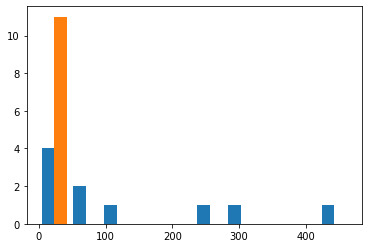

In [14]:
a = np.histogram(diameter_list, bins=10)
_ = plt.hist(a, bins=10)
plt.show()

In [15]:
positiveSample_list = findPositiveSamples()

2020-09-13 02:42:14,698 INFO     pid:101 src.dsets:223:__init__ <src.dsets.LunaDataset object at 0x7f7a38963240>: 110706 training samples, 110409 neg, 297 pos, unbalanced ratio


0 CandidateInfoTuple(isNodule_bool=True, diameter_mm=27.44242293, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.943403138251347598519939390311', center_xyz=(-45.29440163, 74.86925386, -97.52812481))
1 CandidateInfoTuple(isNodule_bool=True, diameter_mm=27.07544345, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.481278873893653517789960724156', center_xyz=(-102.571208, -5.186558766, -205.1033412))
2 CandidateInfoTuple(isNodule_bool=True, diameter_mm=23.93362973, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.267957701183569638795986183786', center_xyz=(-93.56243383, -176.0629504, 213.322413))
3 CandidateInfoTuple(isNodule_bool=True, diameter_mm=23.93362973, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.267957701183569638795986183786', center_xyz=(-97.37, -178.69, 207.83))
4 CandidateInfoTuple(isNodule_bool=True, diameter_mm=23.48374545, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.148447286464082095534651426689', center_xyz=(-90.1922382588, 32.9077042197, -127.738768532))
5 CandidateInfoT

2020-09-13 02:42:14,744 INFO     pid:101 src.dsets:223:__init__ <src.dsets.LunaDataset object at 0x7f7a2a228a20>: 484 training samples, 481 neg, 3 pos, unbalanced ratio


1.3.6.1.4.1.14519.5.2.1.6279.6001.121391737347333465796214915391 52 False [52, 76, 396]


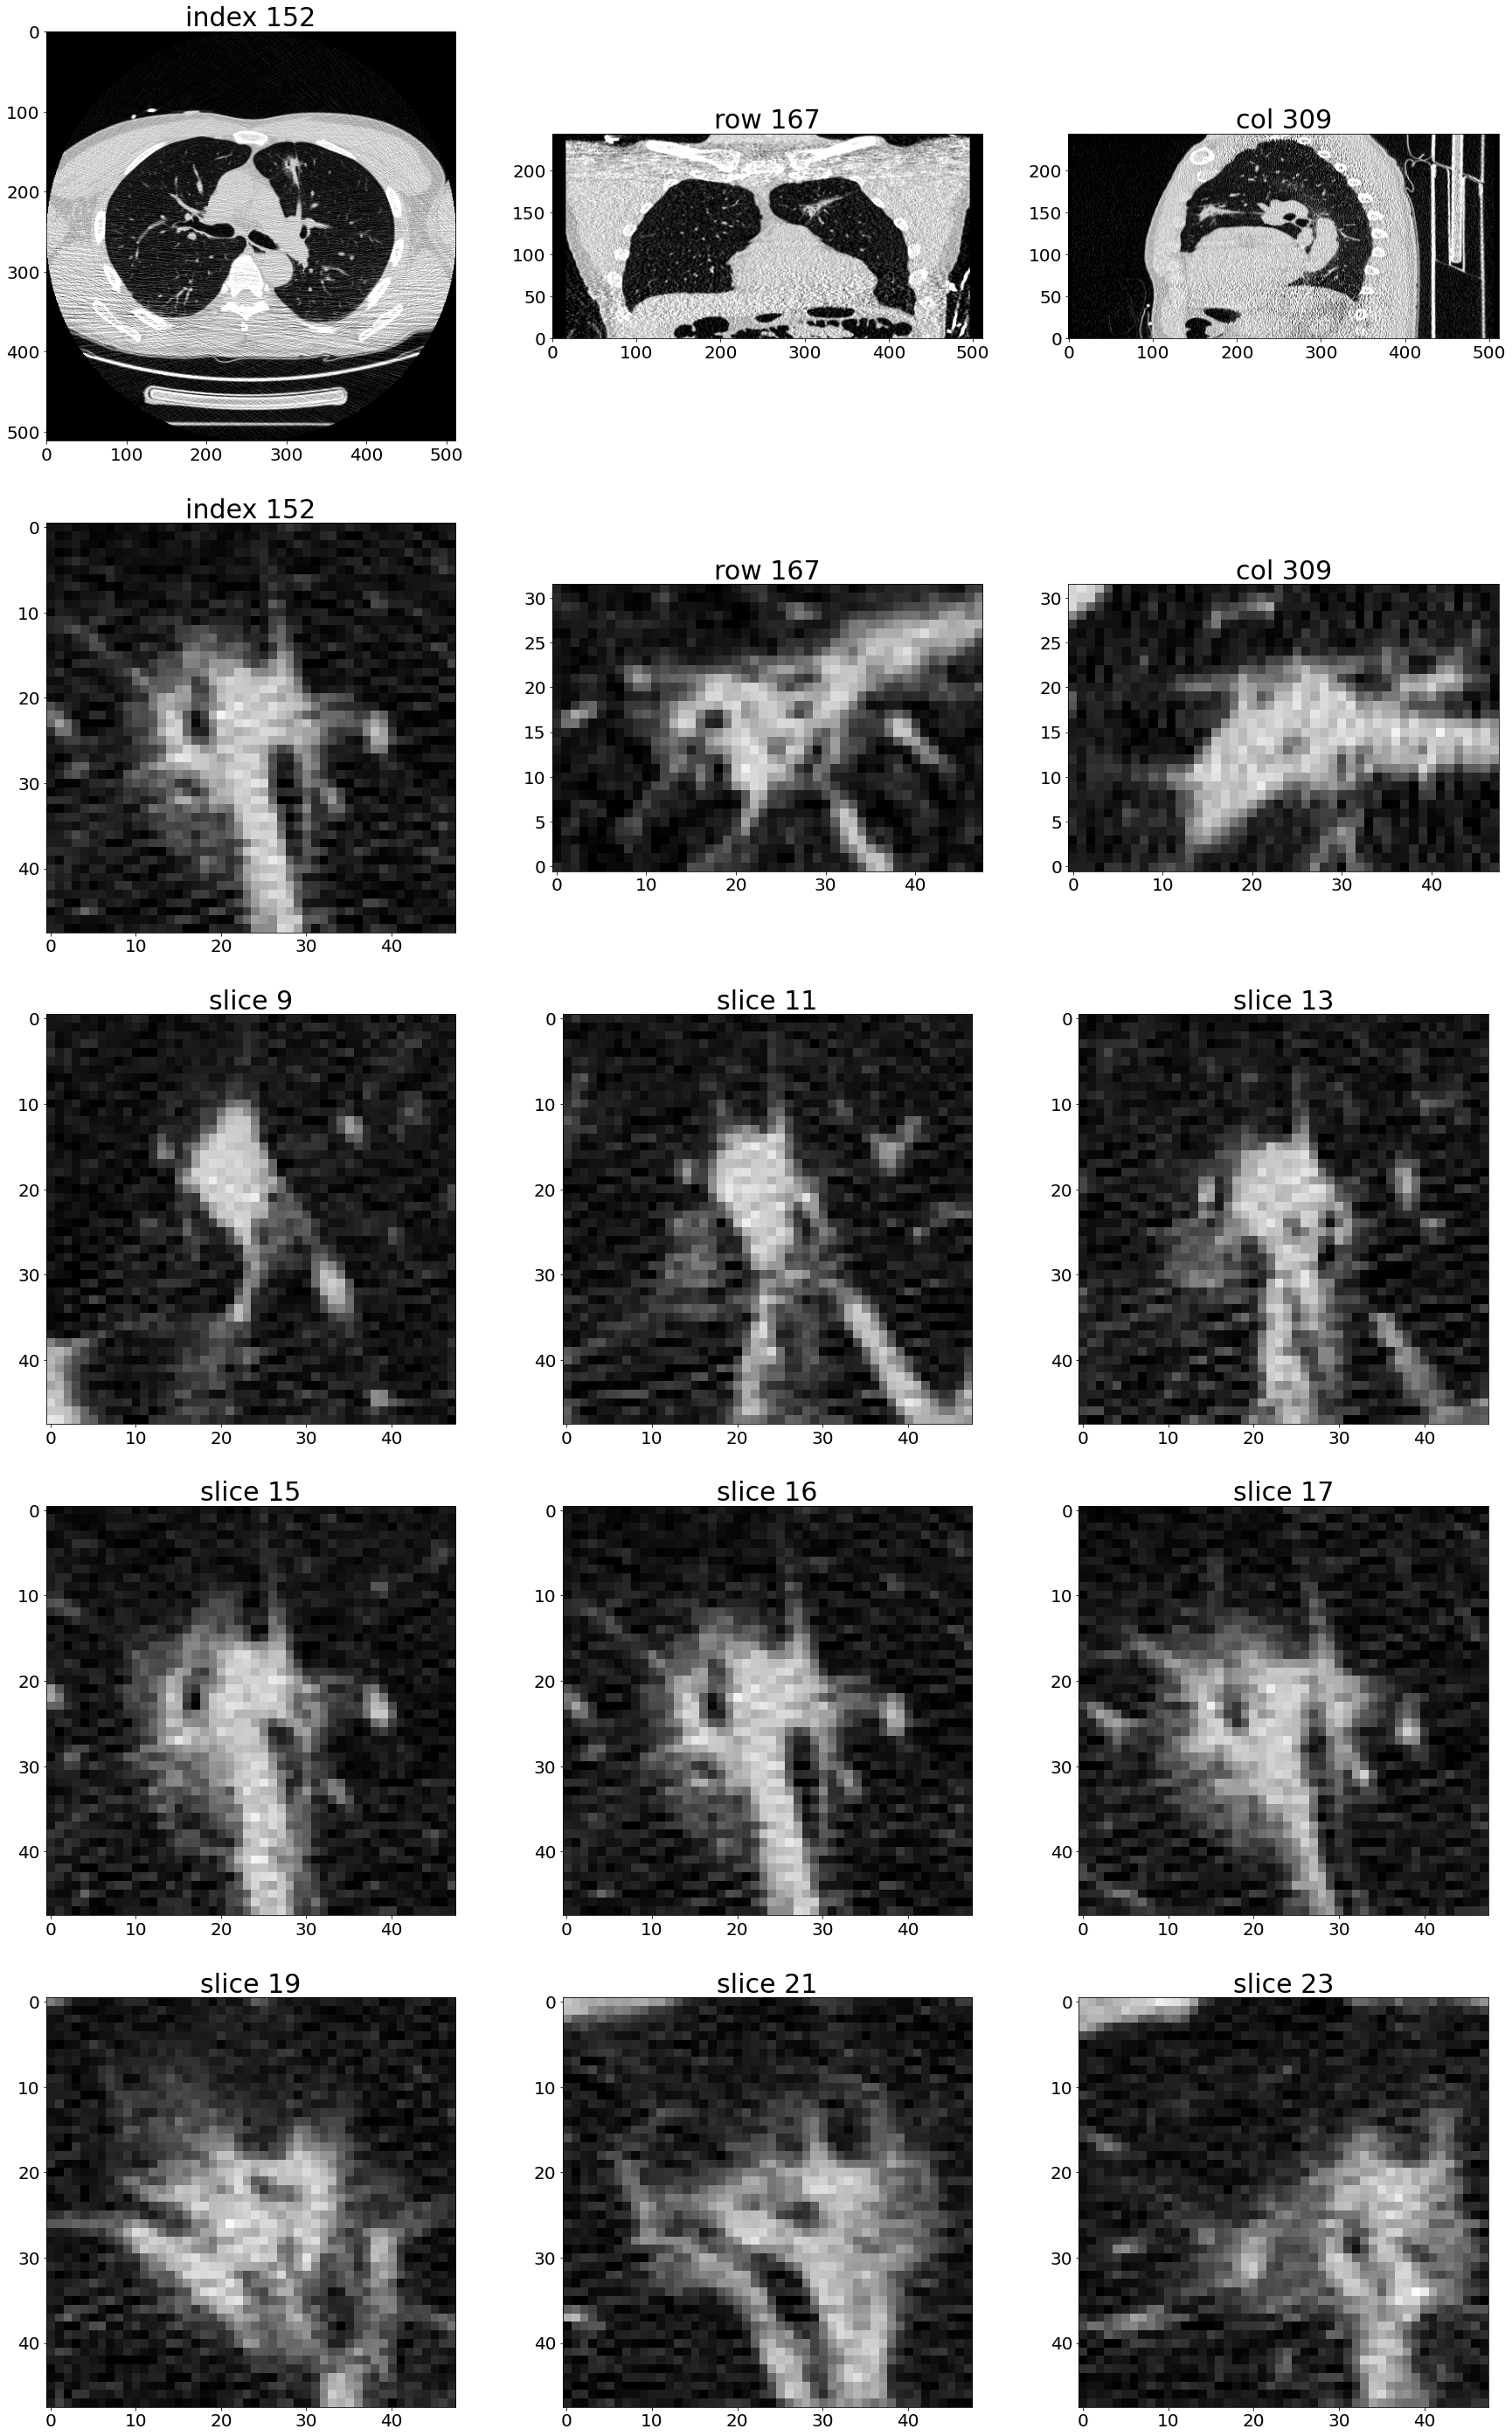

In [16]:
series_uid = positiveSample_list[11][2]
showCandidate(series_uid)

2020-09-13 02:42:21,915 INFO     pid:101 src.dsets:223:__init__ <src.dsets.LunaDataset object at 0x7f7a350993c8>: 484 training samples, 481 neg, 3 pos, unbalanced ratio


1.3.6.1.4.1.14519.5.2.1.6279.6001.121391737347333465796214915391 141 False [141, 205, 358]


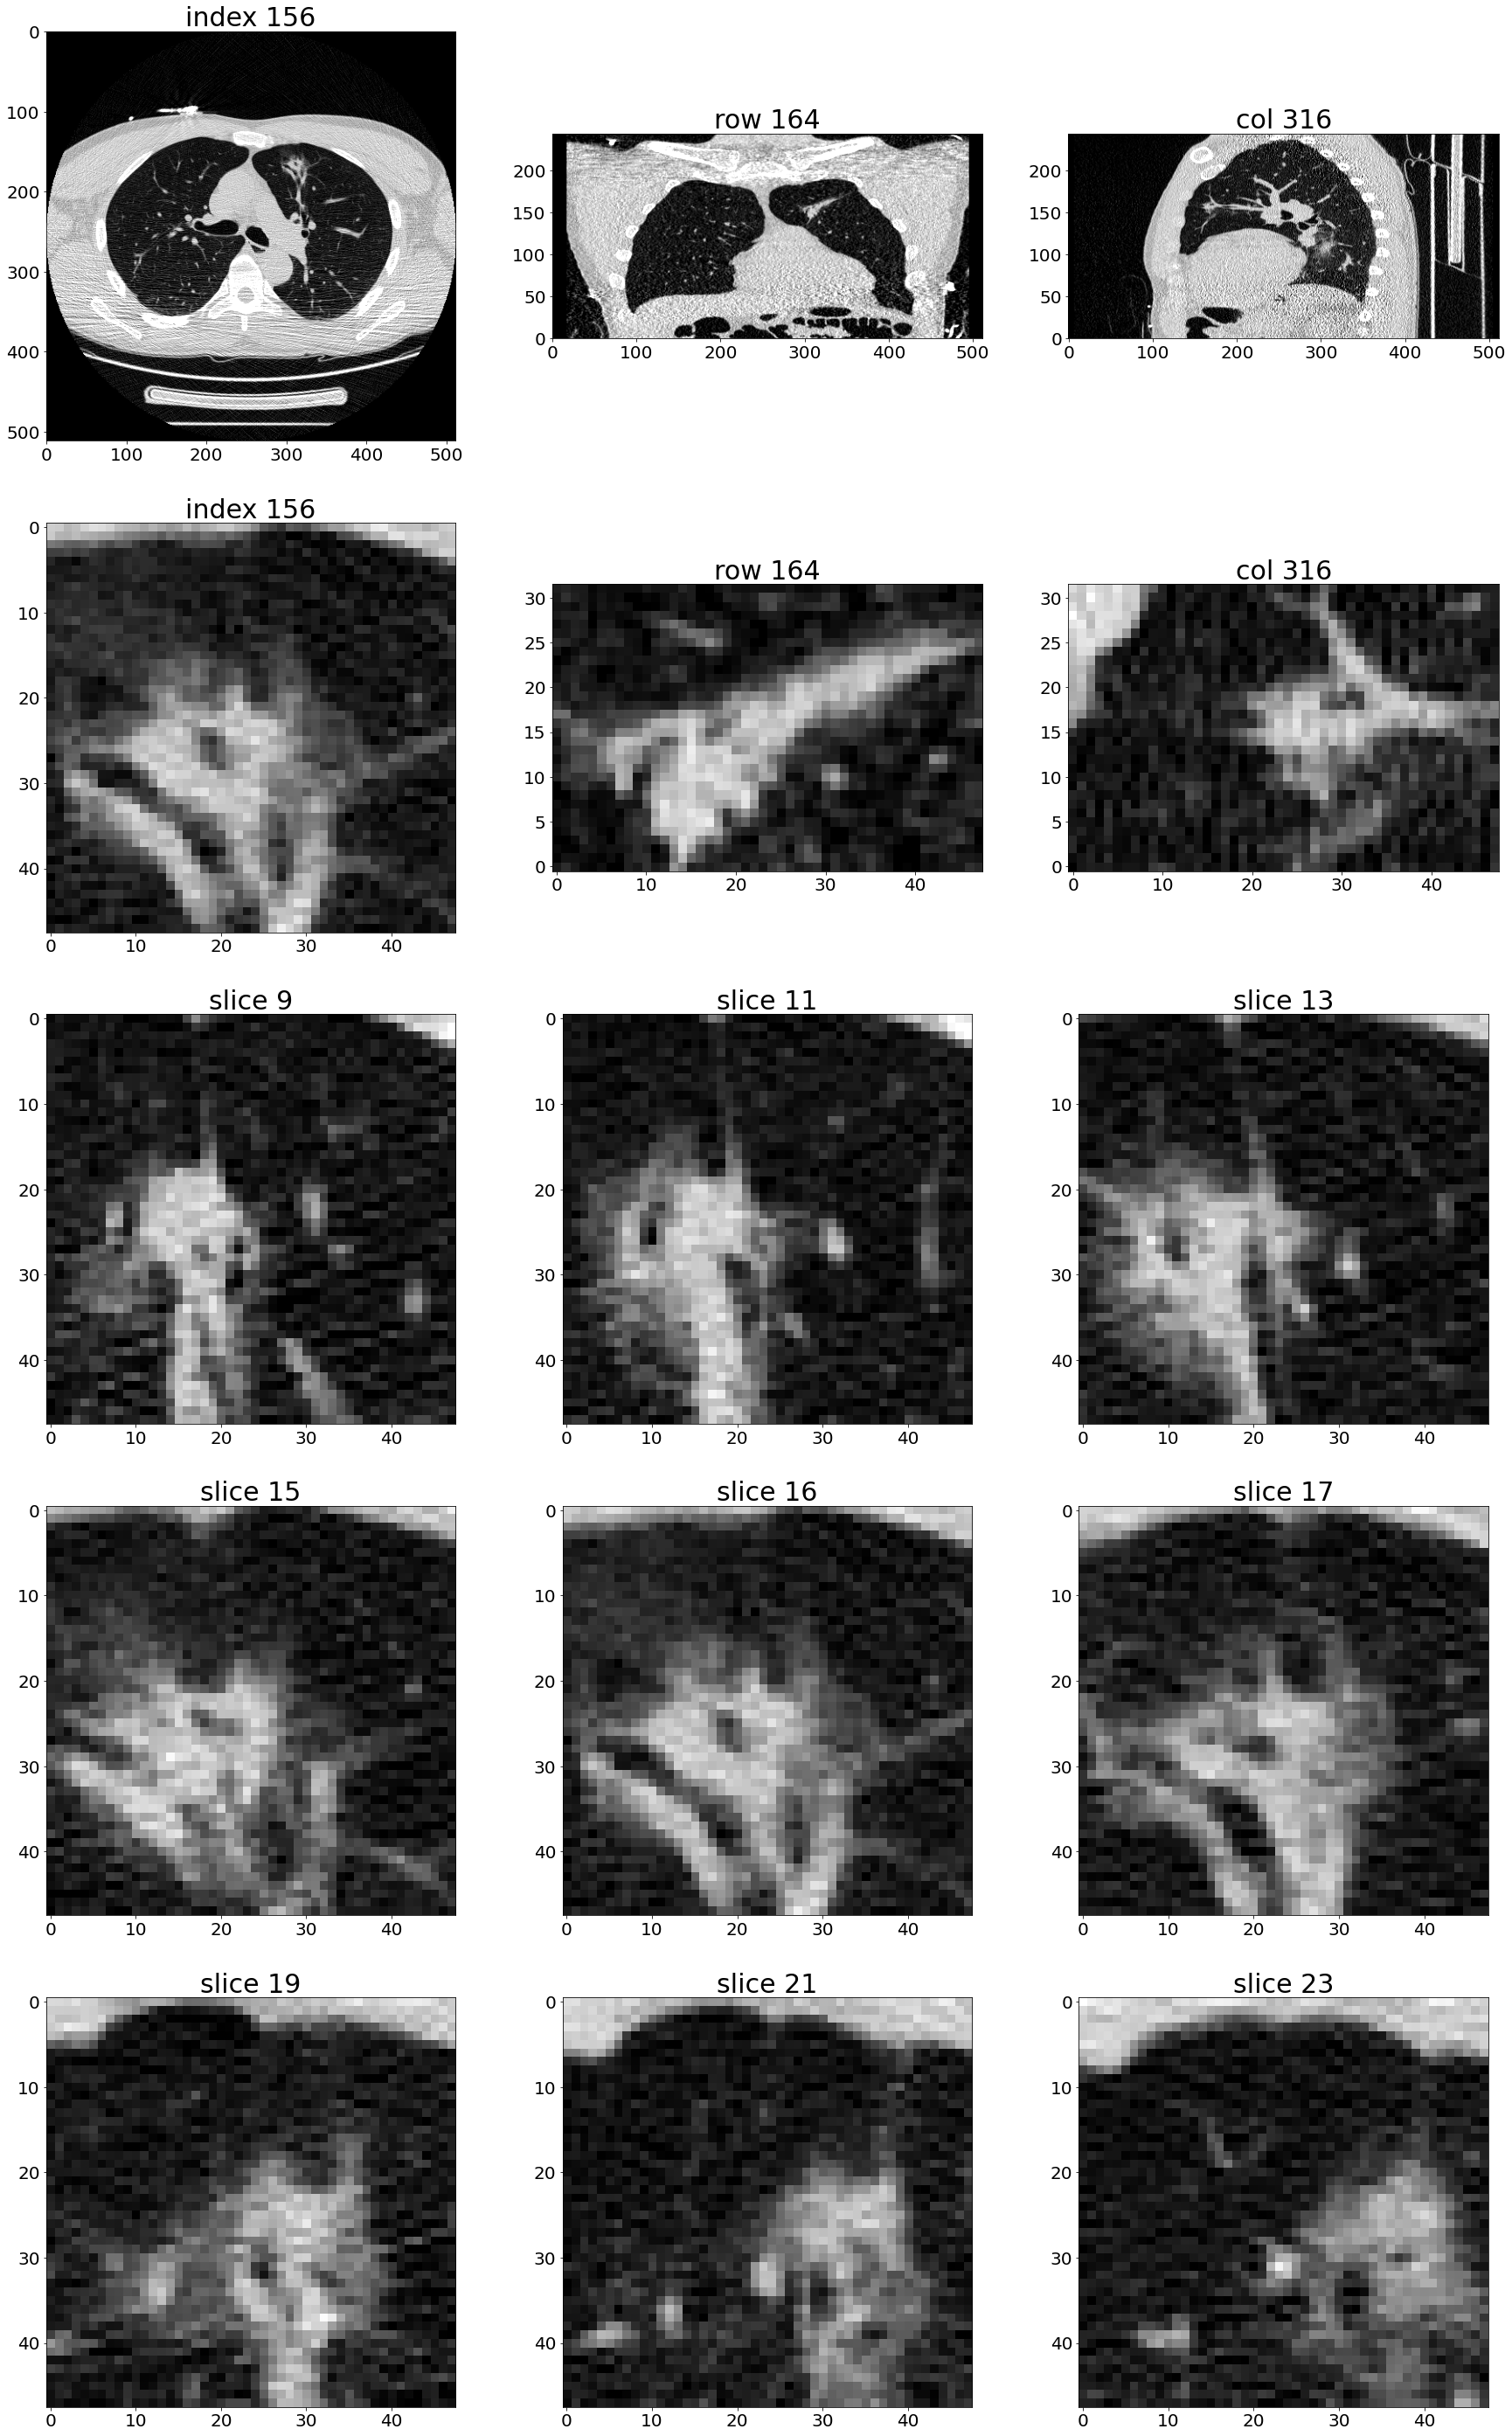

In [17]:
#series_uid = '1.3.6.1.4.1.14519.5.2.1.6279.6001.124154461048929153767743874565'
#showCandidate(series_uid)
series_uid = positiveSample_list[10][2]
showCandidate(series_uid)

2020-09-13 02:42:25,446 INFO     pid:101 src.dsets:223:__init__ <src.dsets.LunaDataset object at 0x7f7a2f99eb38>: 542 training samples, 535 neg, 7 pos, unbalanced ratio


1.3.6.1.4.1.14519.5.2.1.6279.6001.267957701183569638795986183786 37 False [37, 332, 334, 383, 421, 491, 503]


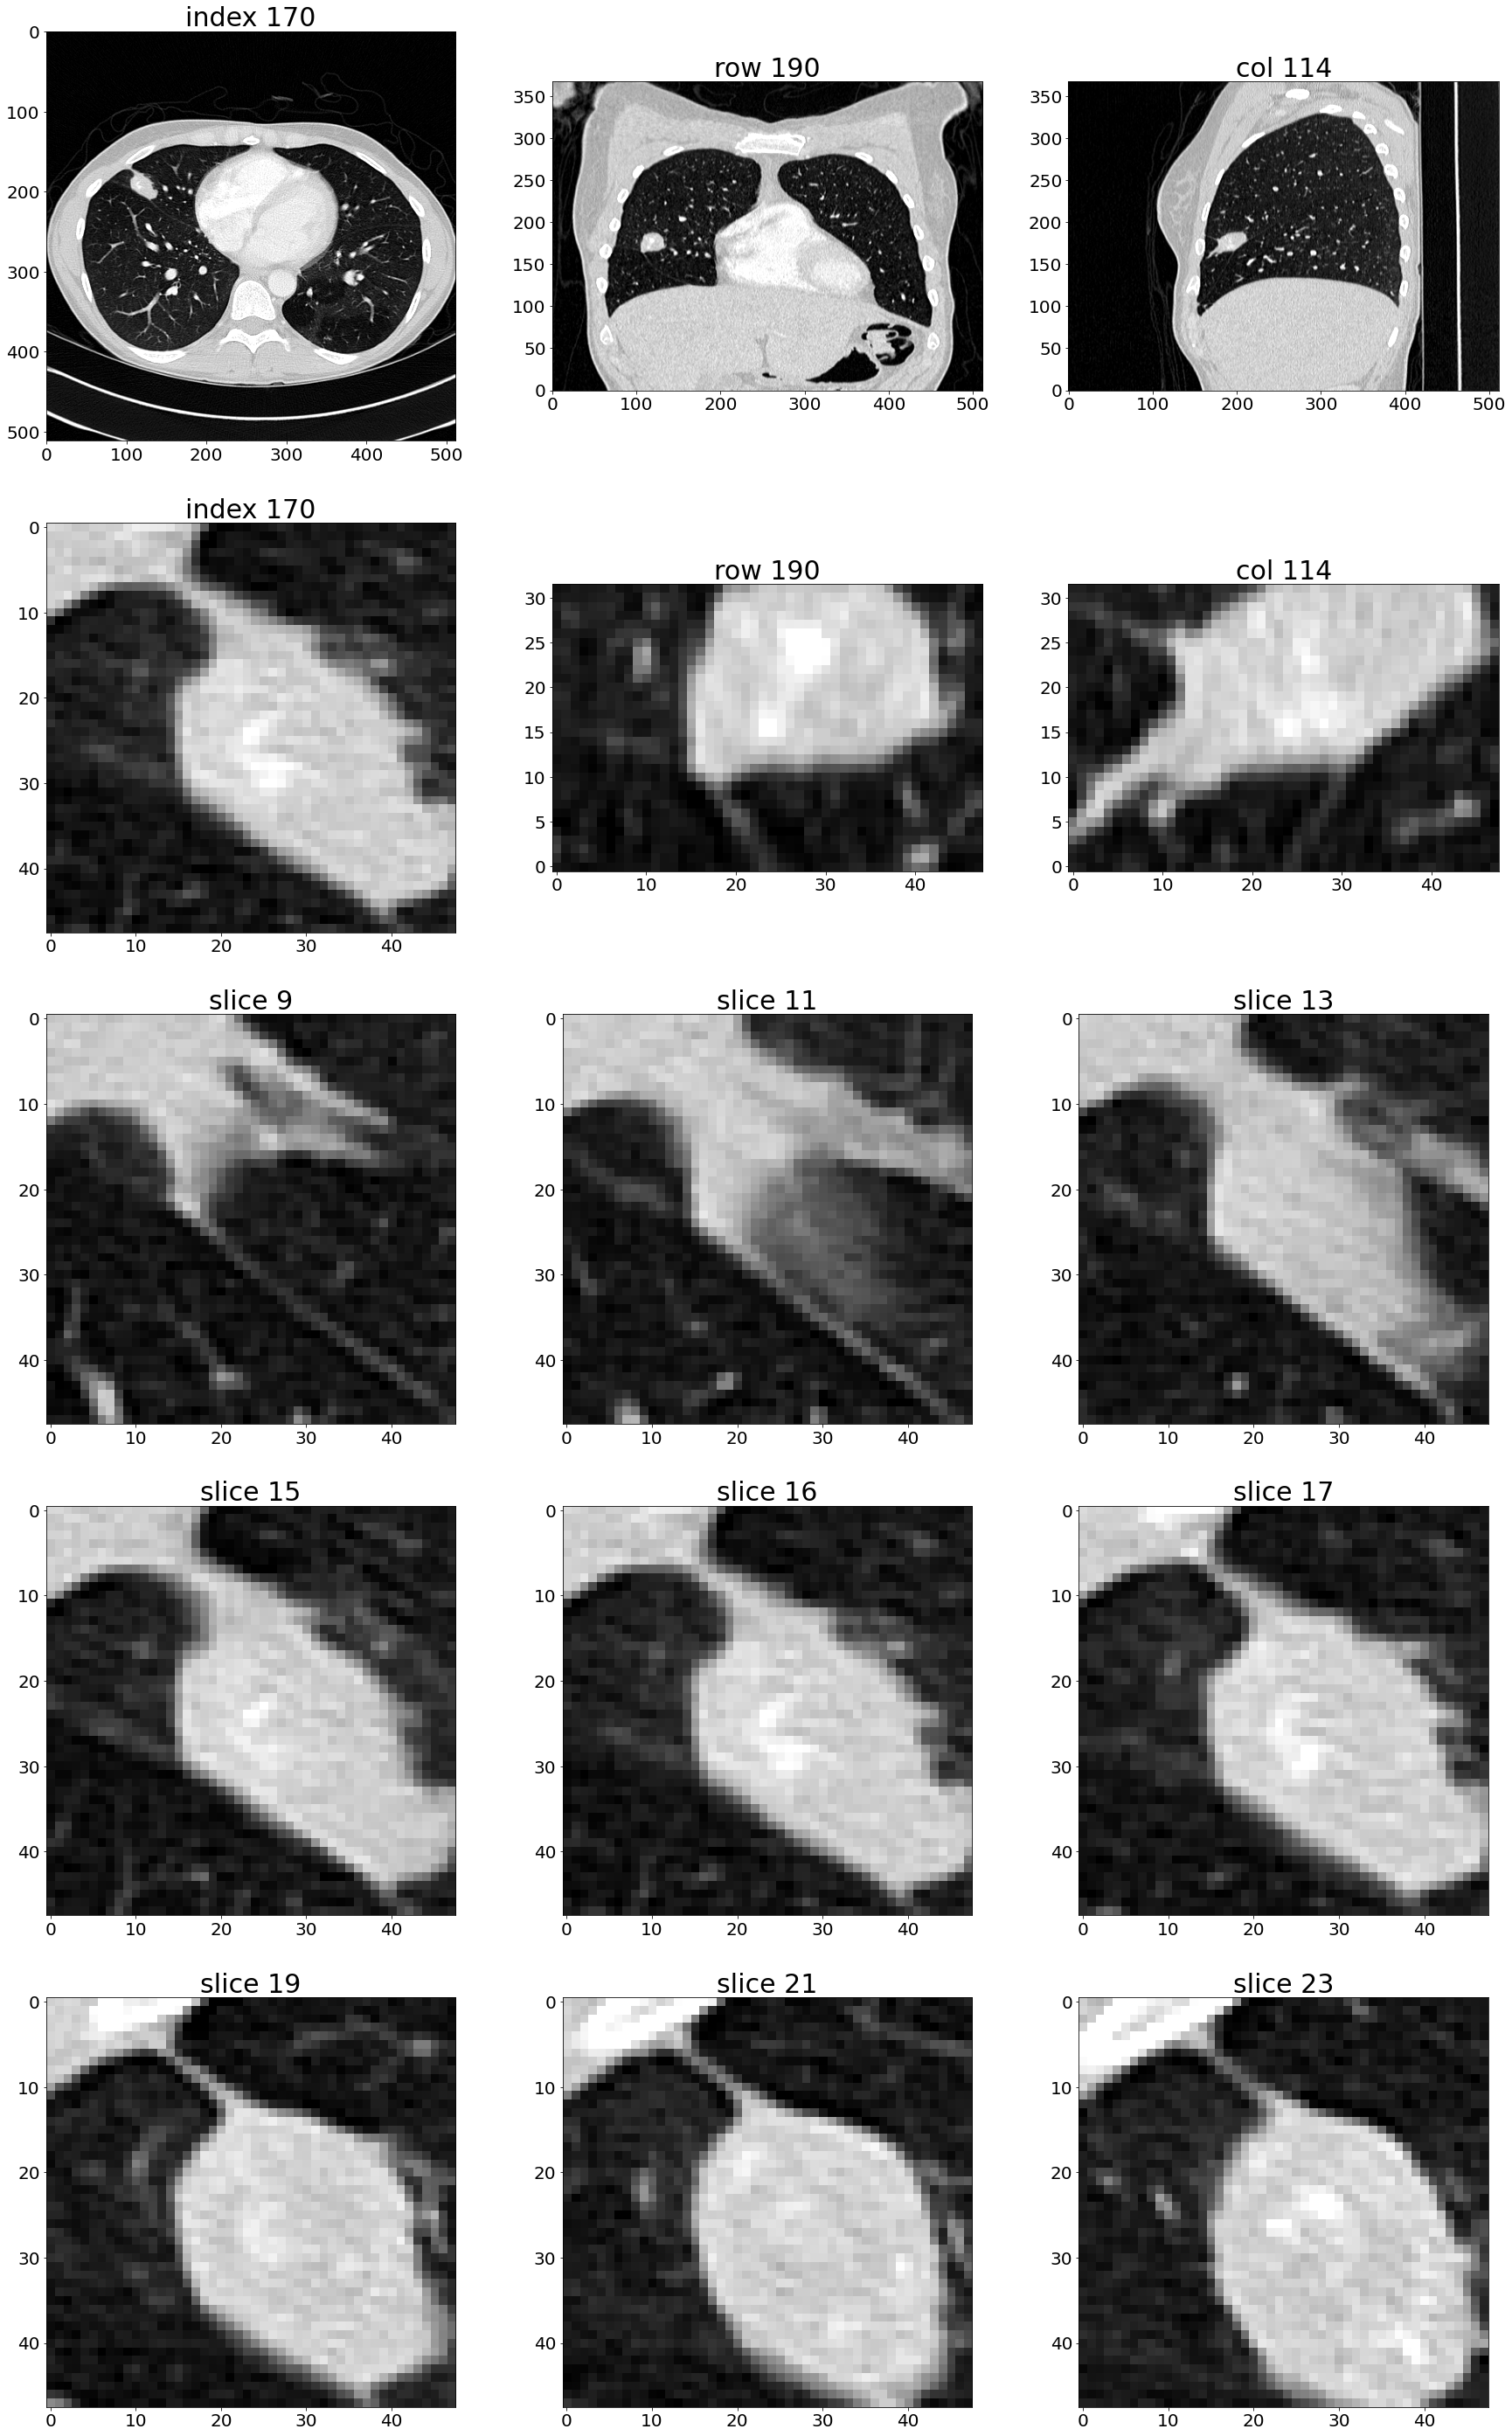

In [18]:
#series_uid = '1.3.6.1.4.1.14519.5.2.1.6279.6001.126264578931778258890371755354'
#showCandidate(series_uid)
series_uid = positiveSample_list[3][2]
showCandidate(series_uid)

# Training a classification model to detect suspected tumor 

In [30]:
%%writefile src/train.py
#importing libaries 
import argparse 
import datetime 
import os 
import sys 
import torch 

import numpy as np 
import torch.nn as nn

from torch.utils.tensorboard import SummaryWriter 
from torch.optim import SGD, Adam 
from torch.utils.data import DataLoader 

from src.util.util import enumerateWithEstimate
from src.dsets import LunaDataset
from src.util.logconf import logging
from src.model import LunaModel

log = logging.getLogger(__name__)
log.setLevel(logging.INFO)
log.setLevel(logging.DEBUG) 

# for computeBatchLoss and logMetrics to index into metrics_t/metrics_a
METRICS_LABEL_NDX=0
METRICS_PRED_NDX=1
METRICS_LOSS_NDX=2
METRICS_SIZE=3 

class LunaTrainingApp:
    def __init__(self, sys_argv=None):
        if sys_argv is None:
            sys_argv = sys.argv[1:] 

        parser = argparse.ArgumentParser() 
        parser.add_argument("--batch-size",
                            help="Batch size to use for training",
                            default=16,
                            type=int,)
        parser.add_argument("--num-workers",
                            help="Number of worker processes for background data loading",
                            default=0,
                            type=int,) 
        parser.add_argument("--epochs",
                             help="Number of epochs to train for",
                             default=1,
                             type=int,)
        parser.add_argument("--balanced",
                            help="Balance the training data to half positive, half negative.",
                            action="store_true",
                            default=False, ) 
        parser.add_argument("--augmented",
                            help="Augment the training data.",
                            action="store_true",
                            default=False, ) 
        parser.add_argument("--augment-flip",
                            help="Augment training data by randomly flipping the data left-right, up-down and front-back.",
                            action="store_true",
                            default=False, ) 
        parser.add_argument("--augment-offset",
                            help="Augment training data by randomly offsetting the data slightly along the X and Y axes.",
                            action="store_true",
                            default=False, ) 
        parser.add_argument("--augment-scale",
                            help="Augment training data by randomly increasing and decreasing the size of the candidate.",
                            action="store_true",
                            default=False, ) 
        parser.add_argument("--augment-rotate",
                            help="Augment training data by randomly rotating the data around the head-foot axis.",
                            action="store_true",
                            default=False, ) 
        parser.add_argument("--augment-noise",
                            help="Augment training data by randomly adding noise to the data.",
                            action="store_true",
                            default=False, ) 
        parser.add_argument("--tb-prefix",
                            help="Data prefix to use for Tensorboard run.",
                            default="src",)
        parser.add_argument("comment",
                            help="Comment suffix for Tensorboard to run.",
                            nargs="?",
                            default="dwlpt",)
        
        self.cli_args = parser.parse_args(sys_argv) 
        self.time_str = datetime.datetime.now().strftime("%Y-%m-%d_%H.%M.%S") 
        self.trn_writer = None 
        self.val_writer = None 
        self.totalTrainingSamples_count = 0 

        self.augmentation_dict = {} 
        if self.cli_args.augmented or self.cli_args.augment_flip:
            self.augmentation_dict["flip"] = True 
        if self.cli_args.augmented or self.cli_args.augment_offset:
            self.augmentation_dict["offset"] = 0.1
        if self.cli_args.augmented or self.cli_args.augment_scale:
            self.augmentation_dict["scale"] = 0.2 
        if self.cli_args.augmented or self.cli_args.augment_rotate:
            self.augmentation_dict["rotate"] = True
        if self.cli_args.augmented or self.cli_args.augment_noise:
            self.augmentation_dict["noise"] = 25.0
       
        self.use_cuda = torch.cuda.is_available() 
        self.device = torch.device("cuda" if self.use_cuda else "cpu")

        self.model = self.initModel() 
        self.optimizer = self.initOptimizer() 

    def initModel(self):
        model = LunaModel()
        if self.use_cuda:
            log.info("Using CUDA; {} devices.".format(torch.cuda.device_count())) 
            if torch.cuda.device_count() > 1: # detecting multiple GPUs
                model = nn.DataParallel(model) # wraps the model 
            model = model.to(self.device)  # send model params to GPU 
        return model 

    def initOptimizer(self):
        return SGD(self.model.parameters(), lr=0.001, momentum=0.99)
    
    def initTrainDl(self):
        train_ds = LunaDataset(val_stride=10, isValSet_bool=False, 
                               ratio_int=int(self.cli_args.balanced),
                               augmentation_dict = self.augmentation_dict,) #Dataset 
        batch_size = self.cli_args.batch_size 
        if self.use_cuda:
            batch_size *= torch.cuda.device_count() 
        
        train_dl = DataLoader(train_ds, batch_size=batch_size,
                                num_workers=self.cli_args.num_workers,
                                pin_memory=self.use_cuda,)
        return train_dl
        
    def initValDl(self):
        val_ds = LunaDataset(val_stride=10, isValSet_bool=True, ) #Val Dataset 
        batch_size = self.cli_args.batch_size 
        if self.use_cuda:
            batch_size *= torch.cuda.device_count()
        
        val_dl = DataLoader(val_ds, batch_size=batch_size, 
                            num_workers=self.cli_args.num_workers, 
                            pin_memory=self.use_cuda,)
        return val_dl 

    def initTensorboardWriters(self):
        if self.trn_writer is None:
            log_dir = os.path.join("runs",  self.cli_args.tb_prefix, self.time_str) 
            self.trn_writer = SummaryWriter(log_dir=log_dir + "-trn_cls-" + self.cli_args.comment)
            self.val_writer = SummaryWriter(log_dir=log_dir + "-val_cls-" + self.cli_args.comment) 

    def main(self):
        log.info("Start {}, {}".format(type(self).__name__, self.cli_args))

        train_dl = self.initTrainDl() 
        val_dl = self.initValDl()

        for epoch_ndx in range(1, self.cli_args.epochs + 1):
            log.info("Epoch {} of {}, {}/{} batches of size {}*{}".format(epoch_ndx,
                                                                          self.cli_args.epochs,
                                                                          len(train_dl),
                                                                          len(val_dl),
                                                                          self.cli_args.batch_size,
                                                                          (torch.cuda.device_count() if self.use_cuda else 1), ))
            
            trnMetrics_t = self.doTraining(epoch_ndx, train_dl) 
            self.logMetrics(epoch_ndx, "trn", trnMetrics_t)

            valMetrics_t = self.doValidation(epoch_ndx, val_dl)
            self.logMetrics(epoch_ndx, "val", valMetrics_t)

        if hasattr(self, "trn_writer"):
            self.trn_writer.close() 
            self.val_writer.close()
    
    def doTraining(self, epoch_ndx, train_dl):
        """
        Steps include:
        1. Load batch tuple 
        2. Classify batch 
        3. Calculate Loss 
        4. Record Metrics 
        5. Update Weights 
        """
        self.model.train()
        train_dl.dataset.shuffleSample()
        trnMetrics_g = torch.zeros(METRICS_SIZE,         # Intializing empty matrix array
                                  len(train_dl.dataset),
                                  device=self.device,) 
        batch_iter = enumerateWithEstimate(train_dl,    # set up batch loop with time estimate 
                                           "E {} Training ".format(epoch_ndx),
                                           start_ndx=train_dl.num_workers,)
        for batch_ndx, batch_tuple in batch_iter:
            self.optimizer.zero_grad()  # Frees any leftover gradient tensors 
            loss_var = self.computeBatchLoss(batch_ndx, batch_tuple, 
                                             train_dl.batch_size, trnMetrics_g,)
            loss_var.backward()
            self.optimizer.step() # update model weight 
        self.totalTrainingSamples_count += len(train_dl.dataset) 
        return trnMetrics_g.to("cpu")

    def doValidation(self, epoch_ndx, val_dl):
        """
        Steps include:
        1. Load batch tuple 
        2. Classify batch 
        3. Calculate Loss 
        4. Record Metrics 
        """
        with torch.no_grad():
            self.model.eval() # turns off training-time behavior 
            valMetrics_g = torch.zeros(METRICS_SIZE, 
                                      len(val_dl.dataset),
                                      device=self.device,)
            batch_iter = enumerateWithEstimate(val_dl,
                                               "E{} Validation ".format(epoch_ndx),
                                               start_ndx=val_dl.num_workers,)
            for batch_ndx, batch_tuple in batch_iter:
                self.computeBatchLoss(batch_ndx, batch_tuple, val_dl.batch_size, valMetrics_g) 
        return valMetrics_g.to("cpu") 

    def computeBatchLoss(self, batch_ndx, batch_tuple, batch_size, metrics_g):
        input_t, label_t, _series_list, _center_list = batch_tuple
        input_g = input_t.to(self.device, non_blocking=True) 
        label_g = label_t.to(self.device, non_blocking=True)

        logits_g, probability_g = self.model(input_g)
        loss_fn = nn.CrossEntropyLoss(reduction="none") # reduction="none" gives the loss per sample 
        loss_g = loss_fn(logits_g, label_g[:,1], ) #index of the one-hot-encoded class

        start_ndx = batch_ndx * batch_size 
        end_ndx = start_ndx + label_t.size(0) 

        metrics_g[METRICS_LABEL_NDX, start_ndx:end_ndx] = label_g[:,1].detach() 
        metrics_g[METRICS_PRED_NDX, start_ndx:end_ndx] = probability_g[:,1].detach() 
        metrics_g[METRICS_LOSS_NDX, start_ndx:end_ndx] = loss_g.detach() 
        return loss_g.mean() #recombines the loss per sample into a single value

    def logMetrics(self, epoch_ndx, mode_str, metrics_t, classificationThreshold=0.5):
        self.initTensorboardWriters()
        log.info("E{} {}".format(epoch_ndx, type(self).__name__, ))

        negLabel_mask = metrics_t[METRICS_LABEL_NDX] <= classificationThreshold 
        negPred_mask = metrics_t[METRICS_PRED_NDX] <= classificationThreshold 
        posLabel_mask = ~negLabel_mask
        posPred_mask = ~negPred_mask

        neg_count = int(negLabel_mask.sum())
        pos_count = int(posLabel_mask.sum())  

        trueNeg_count = neg_correct = int((negLabel_mask & negPred_mask).sum()) # this is equal to trueNeg_count 
        truePos_count = pos_correct = int((posLabel_mask & posPred_mask).sum()) # this is equal to truePos_count

        falsePos_count = neg_count - neg_correct 
        falseNeg_count = pos_count - pos_correct  

        metrics_dict = {} 
        precision = metrics_dict['pr/precision'] = truePos_count / np.float32(truePos_count + falsePos_count) 
        recall = metrics_dict['pr/recall'] = truePos_count / np.float32(truePos_count + falseNeg_count)
        f1_score = metrics_dict['pr/f1_score'] = 2 * (precision * recall) / (precision +  recall)
        metrics_dict["loss/all"] = metrics_t[METRICS_LOSS_NDX].mean() 
        metrics_dict["loss/neg"] = metrics_t[METRICS_LOSS_NDX, negLabel_mask].mean() 
        metrics_dict["loss/pos"] = metrics_t[METRICS_LOSS_NDX, posLabel_mask].mean() 
        metrics_dict["correct/all"] = (pos_correct + neg_correct) / np.float(metrics_t.shape[1]) *100 #converting to np.float32 to avoid integer division. 
        metrics_dict["correct/neg"] = neg_correct / np.float32(neg_count) * 100
        metrics_dict["correct/pos"] = pos_correct / np.float32(pos_count) * 100 



        #log.info(("E{} {:8} {loss/all:.4f} loss, "
        #+"{correct/all:-5.1f}% correct, ").format(epoch_ndx, mode_str, **metrics_dict,))

        log.info(("E{} {:8} {loss/all:.4f} loss, "
        + "{correct/all:-5.1f}% correct, "
        + "{pr/precision:.4f} precision, "
        + "{pr/recall:.4f} recall, "
        + "{pr/f1_score:.4f} f1 score").format(epoch_ndx, mode_str, **metrics_dict,))

        log.info(("E{} {:8} {loss/neg:.4f} loss, "
        + "{correct/neg:-5.1f}% correct ({neg_correct:} of {neg_count:})").format(epoch_ndx, mode_str + '_neg', 
                                                                                  neg_correct=neg_correct, 
                                                                                  neg_count=neg_count, 
                                                                                  **metrics_dict, ))
        log.info(("E{} {:8} {loss/pos:.4f} loss, "
        + "{correct/pos:-5.1f}% correct ({pos_correct:} of {pos_count:})").format(epoch_ndx, mode_str + '_pos',
                                                                                  pos_correct=pos_correct,
                                                                                  pos_count=pos_count,
                                                                                  **metrics_dict, ))

        #log.info(("E{} {:8} {loss/all:.4f} loss, "
        #+"{correct/pos:-5.1f}% correct {pr/precision:.4f} precision, {pr/recall:.4f} recall, "
        #+ "{pr/f1score:.4f} f1 score").format(epoch_ndx, mode_str, pos_correct=pos_correct,**metrics_dict,))


        #log.info(("E{} {:8} {loss/neg:.4f} loss, "
        #+"{correct/neg:-5.1f}% correct ((neg_correct:) of (neg_count:))").format(epoch_ndx, mode_str + "_neg",
        #                                                                         neg_correct=neg_correct,
        #                                                                         neg_count=neg_count,
        #                                                                         **metrics_dict,))
        
        #log.info(("E{} {:8} {loss/pos:.4f} loss, "
        #+"{correct/pos:-5.1f}% correct ((pos_correct:) of (pos_count:))").format(epoch_ndx, mode_str + "_pos",
        #                                                                         pos_correct=pos_correct,
        #                                                                         pos_count=pos_count,
        #                                                                         **metrics_dict,))

        writer = getattr(self, mode_str + "_writer") 
        for key, value in metrics_dict.items():
            writer.add_scalar(key, value, self.totalTrainingSamples_count)
        writer.add_pr_curve("pr", metrics_t[METRICS_LABEL_NDX], metrics_t[METRICS_PRED_NDX],
                            self.totalTrainingSamples_count,)
        
        bins = [x/50.0 for x in range(51)]

        negHist_mask = negLabel_mask & (metrics_t[METRICS_PRED_NDX] > 0.01)
        posHist_mask = posLabel_mask & (metrics_t[METRICS_PRED_NDX] < 0.99)

        if negHist_mask.any():
            writer.add_histogram('is_neg', metrics_t[METRICS_PRED_NDX, negHist_mask],
                                 self.totalTrainingSamples_count, bins=bins, )
        if posHist_mask.any():
            writer.add_histogram('is_pos', metrics_t[METRICS_PRED_NDX, posHist_mask],
                                 self.totalTrainingSamples_count, bins=bins, )
        

if __name__ == "__main__":
    LunaTrainingApp().main()

Overwriting src/train.py


In [20]:
%%writefile src/model.py
#importing libaries 
import math 
import torch.nn as nn
from src.util.logconf import logging 

log = logging.getLogger(__name__)
log.setLevel(logging.DEBUG) 

class LunaBlock(nn.Module):
    def __init__(self, in_channels, conv_channels):
        super().__init__()

        self.conv1 = nn.Conv3d(in_channels=in_channels, out_channels=conv_channels,
                               kernel_size=3, padding=1, bias=True, ) 
        self.relu1 = nn.ReLU(inplace=True) 
        self.conv2 = nn.Conv3d(in_channels=conv_channels, out_channels=conv_channels, 
                               kernel_size=3, padding=1, bias=True, )
        self.relu2 = nn.ReLU(inplace=True) 
        self.maxpool = nn.MaxPool3d(2,2)

    def forward(self, input_batch):
        block_out = self.conv1(input_batch)
        block_out = self.relu1(block_out) 
        block_out = self.conv2(block_out)
        block_out = self.relu2(block_out)
        return self.maxpool(block_out) 


class LunaModel(nn.Module):
    def __init__(self, in_channels=1, conv_channels=8):
        super().__init__() 

        self.tail_batch_norm = nn.BatchNorm3d(1)
        self.block1 = LunaBlock(in_channels,conv_channels)
        self.block2 = LunaBlock(conv_channels, conv_channels*2) 
        self.block3 = LunaBlock(conv_channels*2, conv_channels*4)
        self.block4 = LunaBlock(conv_channels*4, conv_channels*8)

        self.head_linear= nn.Linear(64*2*3*3, 2) 
        self.head_softmax = nn.Softmax(dim=1)
        self._init_weights()

    
    # boilerplate _init_weights function 
    def _init_weights(self):
        for m in self.modules():
            if type(m) in {nn.Linear, nn.Conv3d, nn.Conv2d, nn.ConvTranspose2d, nn.ConvTranspose3d,}:
                nn.init.kaiming_normal_(m.weight.data, a=0, mode='fan_out', nonlinearity='relu',) 
                if m.bias is not None:
                    fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(m.weight.data)
                    bound = 1 / math.sqrt(fan_out) 
                    nn.init.normal_(m.bias, -bound, bound) 

    def forward(self, input_batch):
        bn_output = self.tail_batch_norm(input_batch)
        
        block_out = self.block1(bn_output)
        block_out = self.block2(block_out) 
        block_out = self.block3(block_out) 
        block_out = self.block4(block_out) 

        conv_flat = block_out.view(block_out.size(0), -1, ) #flatten using the batch_size 
        linear_output = self.head_linear(conv_flat) 
        return linear_output, self.head_softmax(linear_output)
        


Writing src/model.py


In [21]:
%%writefile src/prepcache.py
import numpy as np

import torch.nn as nn
from torch.autograd import Variable
from torch.optim import SGD
from torch.utils.data import DataLoader

from src.util.util import enumerateWithEstimate
from src.dsets import LunaDataset
from src.util.logconf import logging
from src.model import LunaModel

log = logging.getLogger(__name__)
log.setLevel(logging.INFO)


class LunaPrepCacheApp:
    @classmethod
    def __init__(self, sys_argv=None):
        if sys_argv is None:
            sys_argv = sys.argv[1:]

        parser = argparse.ArgumentParser()
        parser.add_argument('--batch-size',
                            help='Batch size to use for training',
                            default=1024,
                            type=int, )
        parser.add_argument('--num-workers',
                            help='Number of worker processes for background data loading',
                            default=8,
                            type=int,)
        self.cli_args = parser.parse_args(sys_argv)

    def main(self):
        log.info("Starting {}, {}".format(type(self).__name__, self.cli_args))

        self.prep_dl = DataLoader(LunaDataset(sortby_str='series_uid', ),
                                  batch_size=self.cli_args.batch_size,
                                  num_workers=self.cli_args.num_workers, )

        batch_iter = enumerateWithEstimate(self.prep_dl, "Stuffing cache",
                                           start_ndx=self.prep_dl.num_workers, )
        for _ in batch_iter:
            pass
            
if __name__ == '__main__':
    LunaPrepCacheApp().main()

Writing src/prepcache.py


In [ ]:
# Testing
!python -m src.train --balanced --epochs 1 --batch-size 16

2020-09-13 02:58:58,680 INFO     pid:675 __main__:111:initModel Using CUDA; 1 devices.
2020-09-13 02:59:03,085 INFO     pid:675 __main__:151:main Start LunaTrainingApp, Namespace(augment_flip=False, augment_noise=False, augment_offset=False, augment_rotate=False, augment_scale=False, augmented=False, balanced=True, batch_size=16, comment='dwlpt', epochs=1, num_workers=0, tb_prefix='src')
2020-09-13 02:59:05,284 INFO     pid:675 src.dsets:223:__init__ <src.dsets.LunaDataset object at 0x7eff3fb33fd0>: 99635 training samples, 99368 neg, 267 pos, 1:1 ratio
2020-09-13 02:59:05,294 INFO     pid:675 src.dsets:223:__init__ <src.dsets.LunaDataset object at 0x7efedc2ec4a8>: 11071 validation samples, 11041 neg, 30 pos, unbalanced ratio
2020-09-13 02:59:05,294 INFO     pid:675 __main__:162:main Epoch 1 of 1, 12500/692 batches of size 16*1
2020-09-13 02:59:05,356 WARNING  pid:675 src.util.util:069:enumerateWithEstimate E 1 Training  ----/12500, starting
2020-09-13 03:05:35,002 INFO     pid:675 src.

In [ ]:
!python -m src.train --epochs 1 --batch-size 16

In [23]:
# run_everything.ipynb 

# importing lib
"""
import datetime 

from src.util.util import importstr 
from src.util.logconf import logging 
log = logging.getLogger("nb") 

def run(app, *argv):
    argv = list(argv) 
    argv.insert(0, "--num-workers=4") # check the number of core present and change if needed. 
    log.info("Running: {} ({!r}).main()".format(app, argv))

    app_cls = importstr(*app.rsplit(".", 1))
    app_cls(argv).main()

    log.info("Finished: {}.{!r}).main()".format(app, argv))




run('src.train.LunaTrainingApp','--epochs=1')

"""


'\nimport datetime \n\nfrom src.util.util import importstr \nfrom src.util.logconf import logging \nlog = logging.getLogger("nb") \n\ndef run(app, *argv):\n    argv = list(argv) \n    argv.insert(0, "--num-workers=4") # check the number of core present and change if needed. \n    log.info("Running: {} ({!r}).main()".format(app, argv))\n\n    app_cls = importstr(*app.rsplit(".", 1))\n    app_cls(argv).main()\n\n    log.info("Finished: {}.{!r}).main()".format(app, argv))\n\n\n\n\nrun(\'src.train.LunaTrainingApp\',\'--epochs=1\')\n\n'

In [24]:
!ls -1 "/content/drive/My Drive/Data/Test/subset"?/* | wc -l
!ls -1 "/content/drive/My Drive/Data/Test/subset1"/* | wc -l
!ls -1 "/content/drive/My Drive/Data/Test/subset2"/* | wc -l

356
ls: cannot access '/content/drive/My Drive/Data/Test/subset1/*': No such file or directory
0
178


In [25]:
from src.util.util import enumerateWithEstimate
import time 
import random

for i, _ in enumerateWithEstimate(list(range(234)), "sleeping"):
    time.sleep(random.random())


2020-09-13 02:42:48,412 WARNING  pid:101 src.util.util:069:enumerateWithEstimate sleeping ----/234, starting
2020-09-13 02:42:50,940 INFO     pid:101 src.util.util:083:enumerateWithEstimate sleeping    4/234, done at 2020-09-13 02:44:46, 0:01:58
2020-09-13 02:42:55,421 INFO     pid:101 src.util.util:083:enumerateWithEstimate sleeping   16/234, done at 2020-09-13 02:44:24, 0:01:36
2020-09-13 02:43:23,359 INFO     pid:101 src.util.util:083:enumerateWithEstimate sleeping   64/234, done at 2020-09-13 02:44:54, 0:02:05


KeyboardInterrupt: ignored

In [ ]:
!ls -lA runs/src/
!tensorboard --logdir runs/  #running tensorboard